In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/Telco_Churn_Cleaned.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,num_services
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1yr,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,2-4yr,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1yr,2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,2-4yr,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1yr,0


In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn']
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_group,num_services
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0-1yr,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,2-4yr,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0-1yr,2
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,2-4yr,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0-1yr,0


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42)

In [ ]:
import joblib
preprocessor = joblib.load("../models/preprocessor.pkl")

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [10]:
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrame
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)
X_train_processed.head()

,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,cat__PhoneService_No,cat__PhoneService_Yes,cat__MultipleLines_No,cat__MultipleLines_No phone service,...,cat__tenure_group_0-1yr,cat__tenure_group_1-2yr,cat__tenure_group_2-4yr,cat__tenure_group_4-6yr,cat__tenure_group_nan,remainder__SeniorCitizen,remainder__tenure,remainder__MonthlyCharges,remainder__TotalCharges,remainder__num_services
3738,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,35.0,49.20,1701.65,3.0
3151,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,15.0,75.10,1151.55,1.0
4860,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,13.0,40.55,590.35,3.0
3867,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,26.0,73.50,1905.70,4.0
3810,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,44.55,44.55,0.0


In [11]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

In [12]:
# Convert back to DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=feature_names,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=feature_names,
    index=X_test.index
)
X_train_scaled.head()

,cat__gender_Female,cat__gender_Male,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,cat__PhoneService_No,cat__PhoneService_Yes,cat__MultipleLines_No,cat__MultipleLines_No phone service,...,cat__tenure_group_0-1yr,cat__tenure_group_1-2yr,cat__tenure_group_2-4yr,cat__tenure_group_4-6yr,cat__tenure_group_nan,remainder__SeniorCitizen,remainder__tenure,remainder__MonthlyCharges,remainder__TotalCharges,remainder__num_services
3738,-0.994336,0.994336,0.969234,-0.969234,0.651557,-0.651557,3.013090,-3.013090,-0.95419,3.013090,...,-0.665406,-0.412129,1.835059,-0.682114,-0.037709,-0.441773,0.102371,-0.521976,-0.262257,0.507935
3151,-0.994336,0.994336,-1.031742,1.031742,-1.534786,1.534786,-0.331885,0.331885,1.04801,-0.331885,...,-0.665406,2.426423,-0.544942,-0.682114,-0.037709,-0.441773,-0.711743,0.337478,-0.503635,-0.570530
4860,-0.994336,0.994336,-1.031742,1.031742,-1.534786,1.534786,3.013090,-3.013090,-0.95419,3.013090,...,-0.665406,2.426423,-0.544942,-0.682114,-0.037709,-0.441773,-0.793155,-0.809013,-0.749883,0.507935
3867,1.005696,-1.005696,-1.031742,1.031742,0.651557,-0.651557,-0.331885,0.331885,1.04801,-0.331885,...,-0.665406,-0.412129,1.835059,-0.682114,-0.037709,-0.441773,-0.263980,0.284384,-0.172722,1.047168
3810,-0.994336,0.994336,-1.031742,1.031742,-1.534786,1.534786,-0.331885,0.331885,1.04801,-0.331885,...,1.502841,-0.412129,-0.544942,-0.682114,-0.037709,-0.441773,-1.281624,-0.676279,-0.989374,-1.109762


In [13]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],  # supports l1 + l2
    'class_weight': ['balanced']
}

from sklearn.model_selection import GridSearchCV

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='roc_auc',   # VERY important for churn
    cv=5,
    n_jobs=-1,
    verbose=1
)


In [14]:
grid_search.fit(X_train_scaled, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.8467501828789009


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [15]:
best_log_reg = grid_search.best_estimator_
y_pred = best_log_reg.predict(X_test_scaled)
y_pred_proba = best_log_reg.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))


Accuracy: 0.7352732434350603
Precision: 0.5008460236886633
Recall: 0.7914438502673797
F1: 0.6134715025906736
ROC AUC: 0.841135136531556


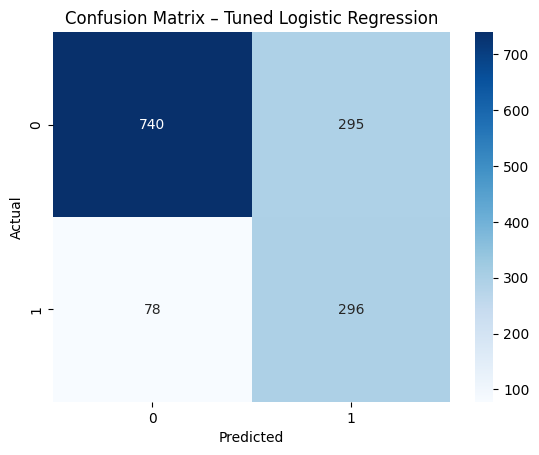

In [16]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Tuned Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': best_log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

feature_importance.head(10)


,Feature,Coefficient
12,cat__InternetService_Fiber optic,0.696097
32,cat__Contract_Month-to-month,0.336996
31,cat__StreamingMovies_Yes,0.289963
28,cat__StreamingTV_Yes,0.285558
50,remainder__num_services,0.237179
49,remainder__TotalCharges,0.222874
10,cat__MultipleLines_Yes,0.191905
44,cat__tenure_group_4-6yr,0.181720
22,cat__DeviceProtection_Yes,0.136273
14,cat__OnlineSecurity_No,0.130776


In [ ]:
feature_importance["Abs_Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance.sort_values(by="Abs_Coefficient", ascending=False).head(15)

,Feature,Coefficient,Abs_Coefficient
48,remainder__MonthlyCharges,-2.072724,2.072724
47,remainder__tenure,-1.099544,1.099544
12,cat__InternetService_Fiber optic,0.696097,0.696097
11,cat__InternetService_DSL,-0.551032,0.551032
34,cat__Contract_Two year,-0.367485,0.367485
32,cat__Contract_Month-to-month,0.336996,0.336996
31,cat__StreamingMovies_Yes,0.289963,0.289963
28,cat__StreamingTV_Yes,0.285558,0.285558
45,cat__tenure_group_nan,-0.269541,0.269541
50,remainder__num_services,0.237179,0.237179


In [ ]:
import joblib

joblib.dump(best_log_reg, "../models/logistic_regression_tuned.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']